# 2.6. Probability and Statistics

Understanding probability and statistics is key to understanding machine learning. Let's dive in!

## 2.6.1. A Simple Example: Tossing Coins

Let's toss a coin. One way to model it in Python is simply by calling the `random.random` method. It returns a random float in the range $[0, 1)$ whose value follows a uniform distribution. We say that we get heads when the result is greater than `0.5` and tails otherwise. This way the probability of heads and tails are both `0.5`.

In [1]:
import random

num_tosses = 100
heads = sum(random.random() > 0.5 for _ in range(num_tosses))
tails = num_tosses - heads
heads, tails

(51, 49)

Another way to model this coin-tossing experiment is by using leveraging a multinomial distribution. A multinomial distribution is a generalization of the binomial distribution with multiple outcomes. Each outcome has a fixed probability with the cumulative probability of all possible outcomes summing up to 1. Each experiment \(attempt\) is independent of the others.

In Numpy, we have the `np.random.multinomial` method to model a multinomial distribution. Let's pass in the following parameters.

1. `n=100`: Number of experiments. Let's pass in `100` to toss our coin 100 times.
1. `pvals=[0.5, 0.5]`: The probability of each outcome. Here, we have `0.5` for both outcomes \(heads and tails\)

In [2]:
import numpy as np

num_tosses = 100
[heads, tails] = np.random.multinomial(n=num_tosses, pvals=[0.5, 0.5])
heads, tails

(47, 53)

Newer versions of Numpy support specifying a random number `Generator` to use for generating random numbers. Let's instantiate the default random number generator with `np.random.default_rng` and invoke its `multinomial` method with the same parameters. This models the same scenario of tossing our fair coin 100 times.

In [3]:
num_tosses = 100
rng = np.random.default_rng()
[heads, tails] = rng.multinomial(n=num_tosses, pvals=[0.5, 0.5])
heads, tails

(52, 48)

Dividing the number of occurrences of each outcome with the total number of experiments gives us the frequency of each outcome. The frequencies of all outcomes sum up to 1.

In [4]:
num_tosses = 100
rng = np.random.default_rng()
[heads_freq, tails_freq] = rng.multinomial(n=num_tosses, pvals=[0.5, 0.5]) / num_tosses
heads_freq, tails_freq

(0.51, 0.49)

Intuitively, as the number of experiments increases, the observed frequency of each outcome should converge towards their underlying probabilities. This intuition is formalized through the following mathematical theorems.

1. Law of large numbers
1. Central limit theorem

Formally, as the sample size $n$ grows, the errors go down at a rate of $\frac{1}{\sqrt{n}}$.

Let's use Numpy's `multinomial` method to visualize the convergence as we repeat our experiment from 1 up to 10000 times. It accepts an optional parameter `size` which specifies the number of samples to obtain. By default, when omitted, it is assumed that `size=1`.

In [5]:
num_tosses = 1
num_samples = 10000
rng = np.random.default_rng()
samples = rng.multinomial(n=num_tosses, pvals=[0.5, 0.5], size=num_samples)
samples

array([[0, 1],
       [1, 0],
       [0, 1],
       ...,
       [1, 0],
       [0, 1],
       [0, 1]])

In [6]:
import mindspore
mindspore.set_device(device_target='Ascend', device_id=0)

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:146: SyntaxWarning: invalid escape sequence '\c'
  2. In forward, tiling would not split c1 and c0, find c1\c0 based on t2.
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:172: SyntaxWarning: invalid escape sequence '\c'
  1. Forward: tiling would not split c1\c0\h0, find c1\c0\h1\h0 based on t2
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangepiaipro-20t/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangep

In [7]:
import mindspore.ops as ops
from mindspore import dtype as mstype

outcomes = mindspore.Tensor(samples, dtype=mstype.float)
outcomes_cumsum = ops.cumsum(outcomes, axis=0)
num_experiments = num_tosses * num_samples
num_experiments_cumcount = num_tosses + ops.arange(num_experiments, step=num_tosses)
outcomes_cumfreq = outcomes_cumsum / ops.transpose(ops.broadcast_to(num_experiments_cumcount, (2, -1)), dims=(1, 0))
heads_cumfreq = outcomes_cumfreq[:, 0]
tails_cumfreq = outcomes_cumfreq[:, 1]
heads_cumfreq, tails_cumfreq

/usr/local/Ascend/cann-8.5.0/python/site-packages/asc_op_compile_base/asc_op_compiler/ascendc_compile_gen_code.py:161: SyntaxWarning: invalid escape sequence '\w'
  match = re.search(f'{option}=(\w+)', ' '.join(compile_options))
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/c

(Tensor(shape=[10000], dtype=Float32, value= [ 0.00000000e+00,  5.00000000e-01,  3.33333343e-01 ...  4.98799771e-01,  4.98749882e-01,  4.98699993e-01]),
 Tensor(shape=[10000], dtype=Float32, value= [ 1.00000000e+00,  5.00000000e-01,  6.66666687e-01 ...  5.01200259e-01,  5.01250148e-01,  5.01299977e-01]))

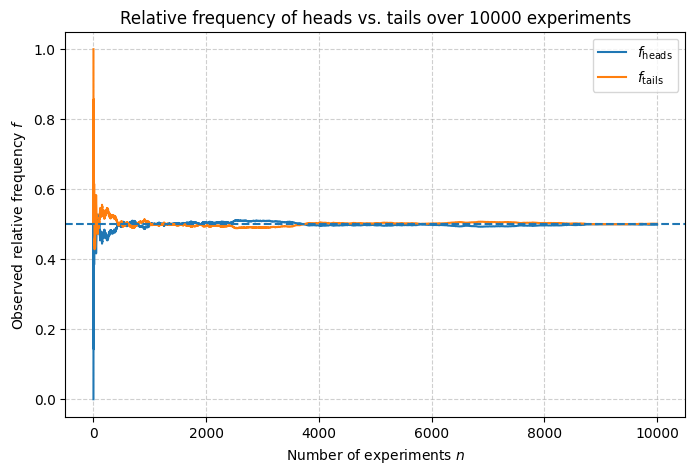

In [8]:
import matplotlib.pyplot as plt

n = num_experiments_cumcount.asnumpy()
f_heads = heads_cumfreq.asnumpy()
f_tails = tails_cumfreq.asnumpy()

plt.figure(figsize=(8, 5))

plt.plot(n, f_heads, label='$f_{\\text{heads}}$', linestyle='-')
plt.plot(n, f_tails, label='$f_{\\text{tails}}$', linestyle='-')
plt.axhline(0.5, linestyle='--')

plt.title(f'Relative frequency of heads vs. tails over {num_experiments} experiments')
plt.xlabel('Number of experiments $n$')
plt.ylabel('Observed relative frequency $f$')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

## 2.6.8. Exercises

Skipped since the remainder of the chapter and exercises are mostly theory and written textbook exercises.